In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import shutil
shutil.rmtree("/content/dataset/test")

In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/train_dataset.zip"
extract_path = "/content/dataset/train"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    for file in zip_ref.namelist():
        # Sadece asl_alphabet_train/ altındaki dosyaları al
        if file.startswith("asl_alphabet_train/") and not file.endswith("/"):
            # Hedef dosya yolu (alt klasörleri koruyor)
            dest_file_path = os.path.join(extract_path, os.path.relpath(file, "asl_alphabet_train"))
            os.makedirs(os.path.dirname(dest_file_path), exist_ok=True)
            with open(dest_file_path, 'wb') as f:
                f.write(zip_ref.read(file))

print("Dosyalar başarıyla çıkarıldı:", extract_path)

Dosyalar başarıyla çıkarıldı: /content/dataset/train


In [ ]:
!pip install -q tensorflow keras opencv-python

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import os
from tensorflow.keras.optimizers import Adam
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.callbacks import Callback
import pickle
import numpy as np
from tensorflow.keras.layers import BatchNormalization

In [ ]:
IMG_SIZE = 224   # MobileNetV2 için ideal
BATCH_SIZE = 16

train_dir = "/content/dataset/train"
test_dir = "/content/dataset/test"

In [ ]:
ignore_classes = ["del", ".ipynb_checkpoints"]

# klasörleri alfabetik sırayla al, ignore_classes'i atla
classes = sorted([cls for cls in os.listdir(train_dir) if cls not in ignore_classes])

print(classes)  # alfabetik sırayla klasörleri gösterir

['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'nothing', 'space']


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import cv2
import numpy as np

# -------------------------------
# 🔥 Custom augmentation (noise + blur)
# -------------------------------
def custom_augment(img):
    img = img.astype(np.float32)

    # 🔹 Random blur
    if np.random.rand() < 0.3:
        img = cv2.GaussianBlur(img, (5, 5), 0)

    # 🔹 Random noise
    if np.random.rand() < 0.3:
        noise = np.random.normal(0, 10, img.shape)
        img = img + noise

    return np.clip(img, 0, 255)

# -------------------------------
# 🔥 Train generator (STRONG augmentation)
# -------------------------------
train_datagen = ImageDataGenerator(
    rescale=1./255,

    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,

    brightness_range=[0.5, 1.5],

    fill_mode='nearest',

    preprocessing_function=custom_augment,

    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    classes=classes,
    shuffle=True
)

# -------------------------------
# ✅ Validation generator (TEMİZ veri)
# -------------------------------
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

val_generator = val_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    classes=classes,
    shuffle=False
)

Found 67200 images belonging to 28 classes.
Found 16800 images belonging to 28 classes.


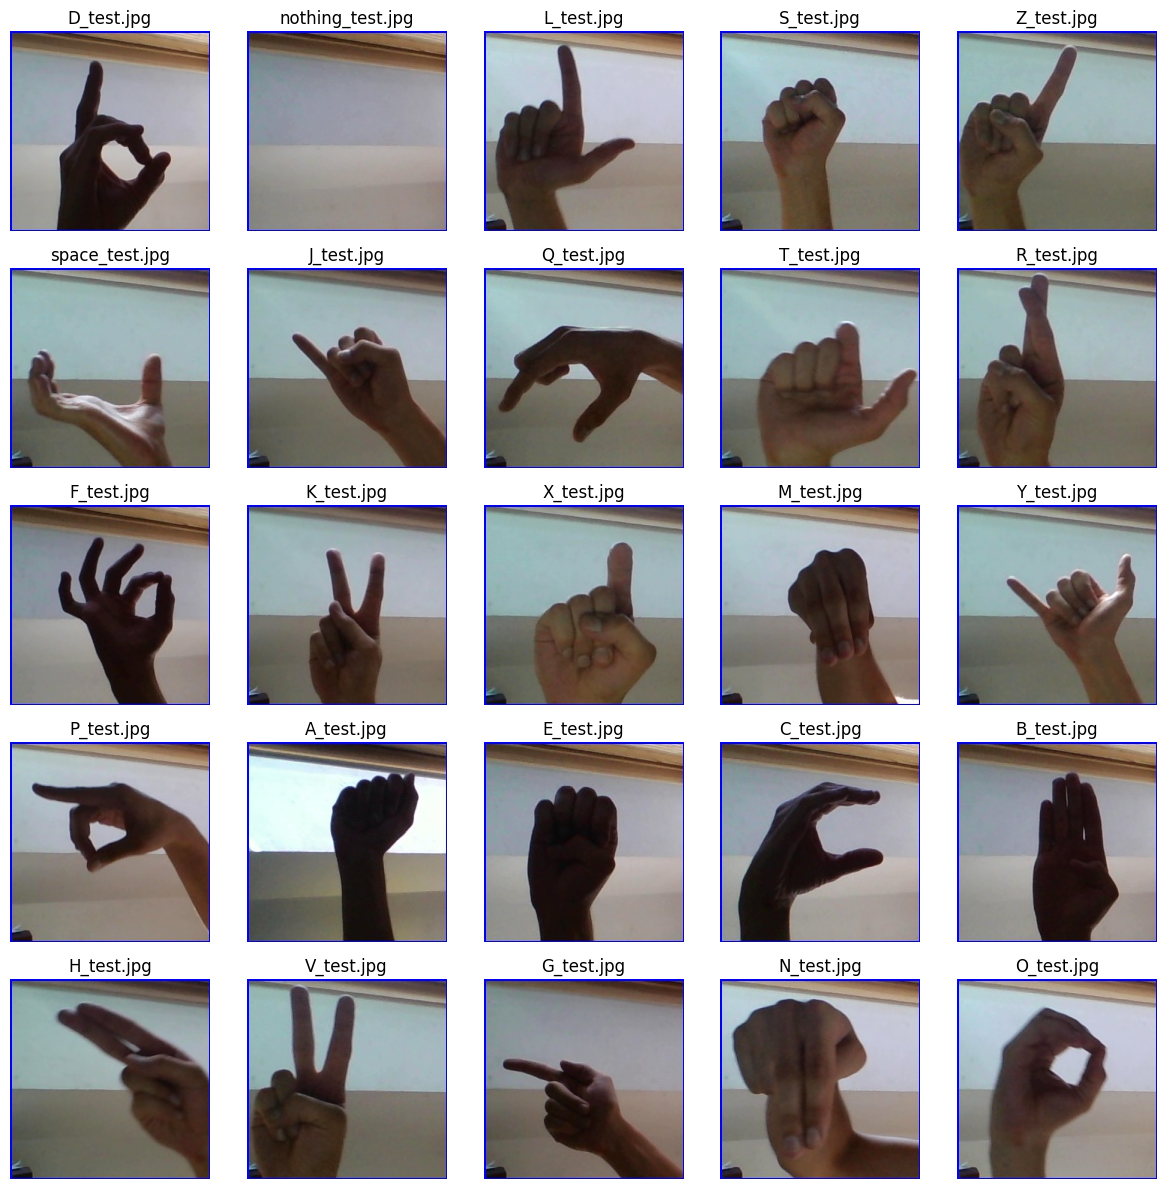

In [ ]:
test_images = os.listdir(test_dir)

plt.figure(figsize=(12,12))

for i, img_name in enumerate(test_images[:25]):  # ilk 25 resmi göster
    img_path = os.path.join(test_dir, img_name)

    img = cv2.imread(img_path)

    if img is None:
        continue  # bozuk dosya varsa atla

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(5,5,i+1)
    plt.imshow(img)
    plt.title(img_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

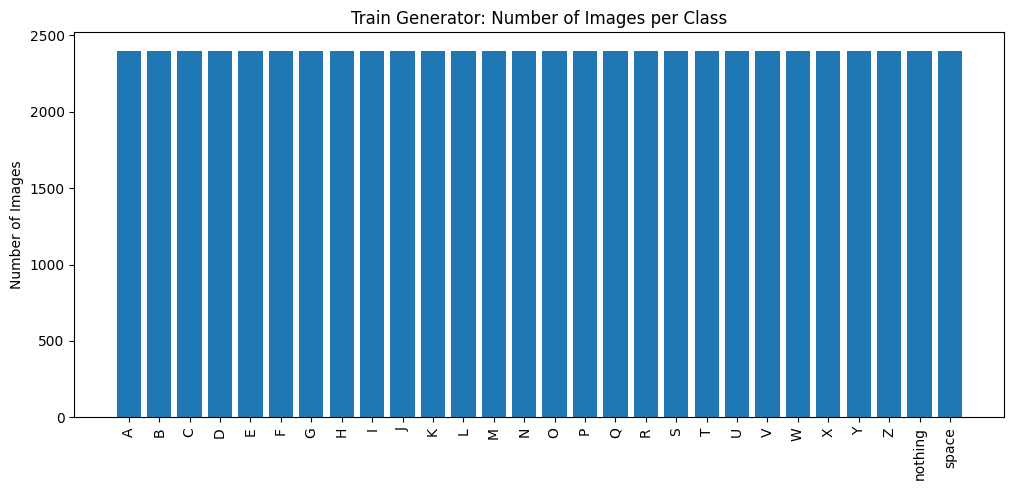

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# class index -> class name mapping
class_labels = {v: k for k, v in train_generator.class_indices.items()}

# her class'tan kaç tane var
counts = np.bincount(train_generator.classes)

# class isimlerini sıraya koy
labels = [class_labels[i] for i in range(len(counts))]

# plot
plt.figure(figsize=(12,5))
plt.bar(labels, counts)
plt.xticks(rotation=90)
plt.title("Train Generator: Number of Images per Class")
plt.ylabel("Number of Images")
plt.show()

In [ ]:
from PIL import Image
sizes = []
for cls in classes:
    cls_path = os.path.join(train_dir, cls)
    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)
        img = Image.open(img_path)
        sizes.append(img.size)

print("Min size:", min(sizes))
print("Max size:", max(sizes))
print("Average size:", (sum([s[0] for s in sizes])/len(sizes),
                           sum([s[1] for s in sizes])/len(sizes)))

Min size: (200, 200)
Max size: (200, 200)
Average size: (200.0, 200.0)


Base train

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2

In [ ]:
# -------------------------------
# 🔥 Base model
# -------------------------------
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# -------------------------------
# 🔥 Freeze (ilk aşama için)
# -------------------------------
for layer in base_model.layers:
    layer.trainable = False

# -------------------------------
# 🔥 Head (daha güçlü + regularized)
# -------------------------------
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = BatchNormalization()(x)

x = Dense(512, activation='relu', kernel_regularizer=l2(0.001))(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)

x = Dense(256, activation='relu', kernel_regularizer=l2(0.001))(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)

output = Dense(train_generator.num_classes, activation='softmax')(x)

# -------------------------------
# Model
# -------------------------------
model = Model(inputs=base_model.input, outputs=output)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# -------------------------------
# 🔥 Model checkpoint
# -------------------------------
checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/AprilModel.keras",
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

# -------------------------------
# 🔥 Early stopping (daha stabil)
# -------------------------------
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,              # ⬆ biraz daha toleranslı
    restore_best_weights=True,
    mode='min',
    verbose=1
)

# -------------------------------
# 🔥 Learning rate scheduler (daha smooth)
# -------------------------------
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,              # ⬆ daha yumuşak düşüş
    patience=3,              # ⬆ biraz daha sabır
    verbose=1,
    min_lr=1e-6
)

In [ ]:
class HistoryCheckpoint(Callback):
    def __init__(self, filename='/content/drive/MyDrive/History/AprilHistory.pkl'):
        self.filename = filename
        os.makedirs(os.path.dirname(self.filename), exist_ok=True)

        # Eğer daha önce kayıt varsa yükle (çok önemli 🔥)
        if os.path.exists(self.filename):
            with open(self.filename, 'rb') as f:
                self.history = pickle.load(f)
            print("Önceki history yüklendi")
        else:
            self.history = {}

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}

        # Her epoch'ta değerleri ekle
        for key, value in logs.items():
            if key not in self.history:
                self.history[key] = []
            self.history[key].append(value)

        # Kaydet (artık overwrite yok, accumulate var)
        with open(self.filename, 'wb') as f:
            pickle.dump(self.history, f)

        print(f"Epoch {epoch+1}: History güncellendi -> {self.filename}")


# Callback oluştur
history_ckpt = HistoryCheckpoint('/content/drive/MyDrive/History/AprilHistory.pkl')

Önceki history yüklendi


In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    initial_epoch=9,
    verbose=1,
    callbacks=[checkpoint, early_stop, reduce_lr,history_ckpt]
)

Epoch 10/10
4200/4200 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step - accuracy: 0.7576 - loss: 1.4509
Epoch 10: val_loss improved from None to 1.39850, saving model to /content/drive/MyDrive/AprilModel.keras

Epoch 10: finished saving model to /content/drive/MyDrive/AprilModel.keras
Epoch 10: History güncellendi -> /content/drive/MyDrive/History/AprilHistory.pkl
4200/4200 ━━━━━━━━━━━━━━━━━━━━ 1122s 262ms/step - accuracy: 0.7549 - loss: 1.5186 - val_accuracy: 0.7950 - val_loss: 1.3985 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 10.


In [ ]:
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/AprilModel.keras")

In [ ]:
loss, acc = model.evaluate(val_generator)
print("Val Loss:", loss)
print("Val Accuracy:", acc)

1050/1050 ━━━━━━━━━━━━━━━━━━━━ 57s 38ms/step - accuracy: 0.7950 - loss: 1.3985
Val Loss: 1.3985016345977783
Val Accuracy: 0.7950000166893005


In [ ]:
model.save("/content/drive/MyDrive/AprilModel.keras")

In [ ]:
with open('/content/drive/MyDrive/History/AprilHistory.pkl', 'rb') as f:
    old_history = pickle.load(f)

In [ ]:
print(old_history.keys())
print(len(old_history['accuracy']))

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate'])
10


In [ ]:
print(old_history['accuracy'])

[0.6278720498085022, 0.7264583110809326, 0.7330654859542847, 0.7381994128227234, 0.7429018020629883, 0.7865774035453796, 0.7946577668190002, 0.7977678775787354, 0.798630952835083, 0.7548660635948181]


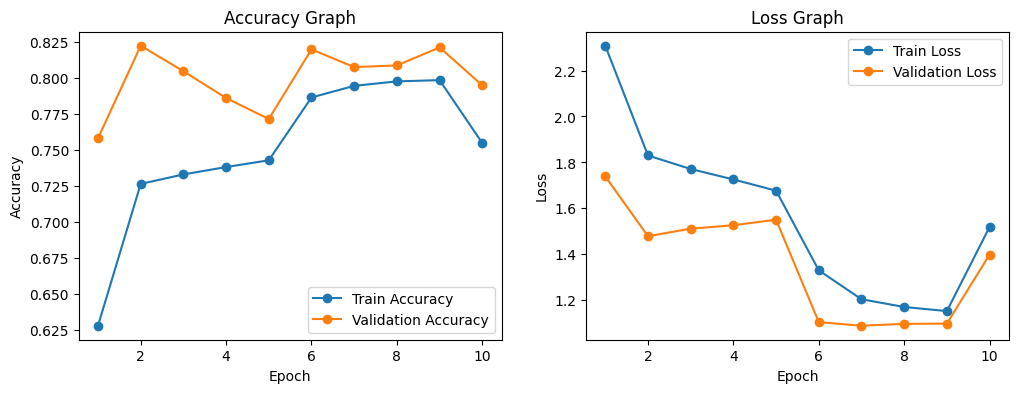

In [ ]:
# 🔹 Epoch sayısı
epochs = range(1, len(old_history['accuracy']) + 1)

plt.figure(figsize=(12,4))

# 🔹 Accuracy grafiği
plt.subplot(1,2,1)
plt.plot(epochs, old_history['accuracy'], marker='o', label='Train Accuracy')
plt.plot(epochs, old_history['val_accuracy'], marker='o', label='Validation Accuracy')
plt.title('Accuracy Graph')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# 🔹 Loss grafiği
plt.subplot(1,2,2)
plt.plot(epochs, old_history['loss'], marker='o', label='Train Loss')
plt.plot(epochs, old_history['val_loss'], marker='o', label='Validation Loss')
plt.title('Loss Graph')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
test_path = "/content/dataset/test"

images = []
labels = []

for file in os.listdir(test_path):
    img_path = os.path.join(test_path, file)

    # resmi oku
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))
    img = img / 255.0

    images.append(img)

    # label çıkar (A_test.jpg → A)
    label = file.split("_")[0]
    labels.append(label)

X_test = np.array(images)

In [ ]:
X_test.shape

(28, 224, 224, 3)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# Prediction
y_pred = model.predict(X_test)
Y_pred_classes = np.argmax(y_pred, axis=1)

# Class mapping
class_indices = train_generator.class_indices
index_to_class = {v: k for k, v in class_indices.items()}

# True label → index'e çevir
Y_true = [class_indices[label] for label in labels]

# Accuracy
accuracy = np.mean(np.array(Y_true) == np.array(Y_pred_classes))
print("\nAccuracy:", accuracy, "\n")

# Classification Report
print("Classification Report:\n")
print(classification_report(Y_true, Y_pred_classes, target_names=list(class_indices.keys())))

1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step

Accuracy: 1.0 

Classification Report:

              precision    recall  f1-score   support

           A       1.00      1.00      1.00         1
           B       1.00      1.00      1.00         1
           C       1.00      1.00      1.00         1
           D       1.00      1.00      1.00         1
           E       1.00      1.00      1.00         1
           F       1.00      1.00      1.00         1
           G       1.00      1.00      1.00         1
           H       1.00      1.00      1.00         1
           I       1.00      1.00      1.00         1
           J       1.00      1.00      1.00         1
           K       1.00      1.00      1.00         1
           L       1.00      1.00      1.00         1
           M       1.00      1.00      1.00         1
           N       1.00      1.00      1.00         1
           O       1.00      1.00      1.00         1
           P       1.00      1.00      1.00         1
  

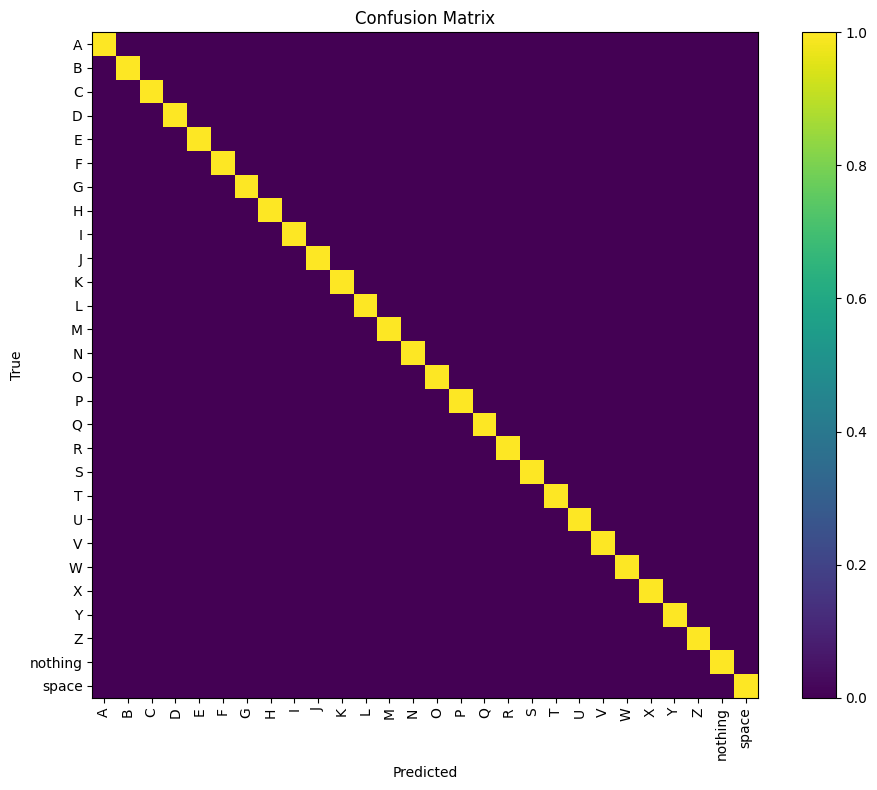

In [ ]:
confusion_mtx = confusion_matrix(Y_true, Y_pred_classes)

plt.figure(figsize=(10, 8))
plt.imshow(confusion_mtx)
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_indices))
plt.xticks(tick_marks, list(class_indices.keys()), rotation=90)
plt.yticks(tick_marks, list(class_indices.keys()))

plt.xlabel("Predicted")
plt.ylabel("True")

plt.tight_layout()
plt.show()

In [ ]:
val_generator.reset()
y_pred = model.predict(val_generator)
Y_pred_classes = np.argmax(y_pred, axis=1)
Y_true = val_generator.classes
Y_pred_classes = Y_pred_classes[:len(Y_true)]

accuracy = np.mean(Y_true == Y_pred_classes)
print("Accuracy:", accuracy)

1050/1050 ━━━━━━━━━━━━━━━━━━━━ 30s 23ms/step
Accuracy: 0.795


Classification Report:

              precision    recall  f1-score   support

           A       0.89      0.77      0.82       600
           B       0.89      0.87      0.88       600
           C       0.98      0.95      0.97       600
           D       0.80      0.94      0.87       600
           E       0.77      0.83      0.79       600
           F       0.99      1.00      0.99       600
           G       0.93      0.79      0.85       600
           H       0.90      0.98      0.94       600
           I       0.62      0.73      0.67       600
           J       0.86      0.66      0.75       600
           K       0.93      0.88      0.90       600
           L       0.87      0.96      0.91       600
           M       0.70      0.85      0.77       600
           N       0.60      0.82      0.70       600
           O       0.83      0.77      0.80       600
           P       0.89      0.72      0.80       600
           Q       0.94      0.87      0.90       600
   

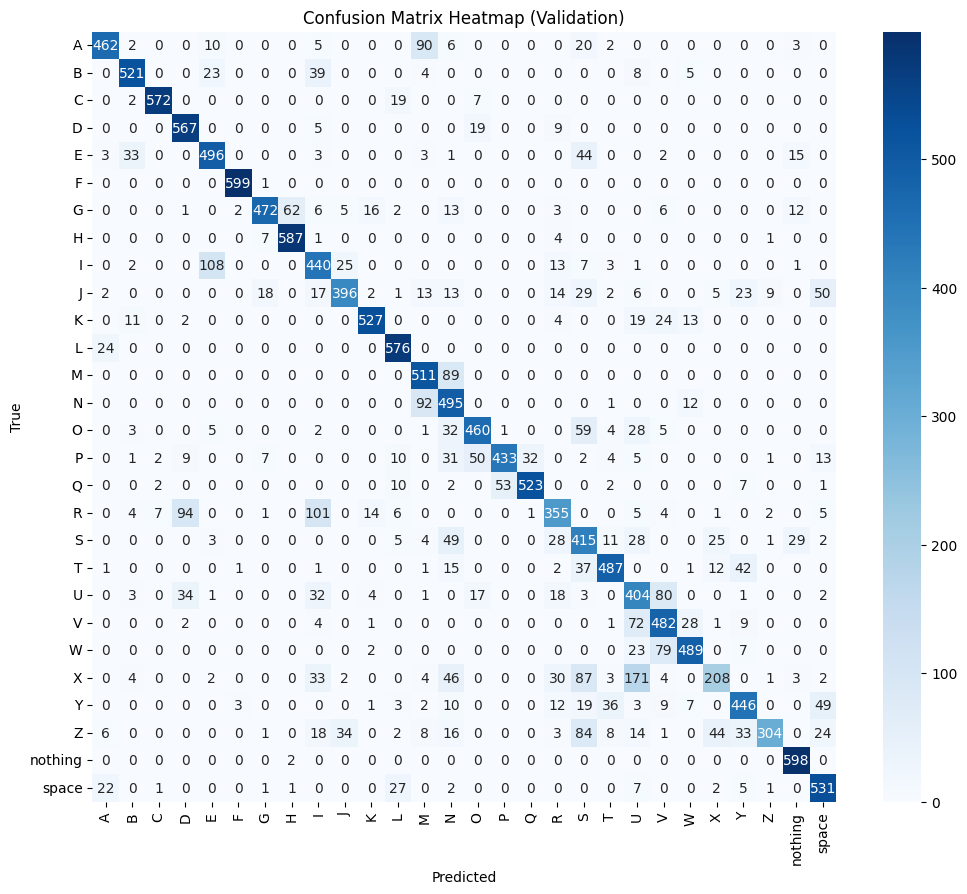

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 🔹 Classification Report
class_labels = list(val_generator.class_indices.keys())
print("Classification Report:\n")
print(classification_report(Y_true, Y_pred_classes, target_names=class_labels))

# 🔹 Confusion Matrix
conf_matrix = confusion_matrix(Y_true, Y_pred_classes)

plt.figure(figsize=(12,10))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix Heatmap (Validation)')
plt.show()

In [ ]:
gap_total = sum(t- v for t, v in zip(old_history['accuracy'], old_history['val_accuracy']))
print(gap_total/10)

-0.04953124523162842


Second step training

In [ ]:
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/AprilModel.keras")

In [ ]:
for i, layer in enumerate(model.layers):
    print(i, layer.name, type(layer))

0 input_layer <class 'keras.src.layers.core.input_layer.InputLayer'>
1 Conv1 <class 'keras.src.layers.convolutional.conv2d.Conv2D'>
2 bn_Conv1 <class 'keras.src.layers.normalization.batch_normalization.BatchNormalization'>
3 Conv1_relu <class 'keras.src.layers.activations.relu.ReLU'>
4 expanded_conv_depthwise <class 'keras.src.layers.convolutional.depthwise_conv2d.DepthwiseConv2D'>
5 expanded_conv_depthwise_BN <class 'keras.src.layers.normalization.batch_normalization.BatchNormalization'>
6 expanded_conv_depthwise_relu <class 'keras.src.layers.activations.relu.ReLU'>
7 expanded_conv_project <class 'keras.src.layers.convolutional.conv2d.Conv2D'>
8 expanded_conv_project_BN <class 'keras.src.layers.normalization.batch_normalization.BatchNormalization'>
9 block_1_expand <class 'keras.src.layers.convolutional.conv2d.Conv2D'>
10 block_1_expand_BN <class 'keras.src.layers.normalization.batch_normalization.BatchNormalization'>
11 block_1_expand_relu <class 'keras.src.layers.activations.relu.Re

In [ ]:
# 1. CNN tamamen freeze
for layer in model.layers[:120]:
    layer.trainable = False

# 2. son CNN bloklarını aç
for layer in model.layers[120:154]:
    layer.trainable = True

# 3. Dense head her zaman trainable
for layer in model.layers[154:]:
    layer.trainable = True

In [ ]:
import tensorflow as tf

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),  # düşük LR fine-tuning için
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 3,089,884 (11.79 MB)

 Trainable params: 2,452,700 (9.36 MB)

 Non-trainable params: 637,184 (2.43 MB)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/bestModel_final_v2.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    verbose=1
)

In [ ]:
class HistoryCheckpoint(Callback):
    def __init__(self, filename='/content/drive/MyDrive/History/AprilHistory_final_v2.pkl'):
        self.filename = filename
        os.makedirs(os.path.dirname(self.filename), exist_ok=True)

        # Eğer daha önce kayıt varsa yükle (çok önemli 🔥)
        if os.path.exists(self.filename):
            with open(self.filename, 'rb') as f:
                self.history = pickle.load(f)
            print("Önceki history yüklendi")
        else:
            self.history = {}

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}

        # Her epoch'ta değerleri ekle
        for key, value in logs.items():
            if key not in self.history:
                self.history[key] = []
            self.history[key].append(value)

        # Kaydet (artık overwrite yok, accumulate var)
        with open(self.filename, 'wb') as f:
            pickle.dump(self.history, f)

        print(f"Epoch {epoch+1}: History güncellendi -> {self.filename}")


# Callback oluştur
history_ckpt2 = HistoryCheckpoint('/content/drive/MyDrive/History/AprilHistory_final_v2.pkl')

Önceki history yüklendi


In [ ]:
history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=60,
    initial_epoch=45,
    verbose=1,
    callbacks=[checkpoint, early_stop, reduce_lr, history_ckpt2]
)

Epoch 46/60
4200/4200 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.9939 - loss: 0.1002
Epoch 46: val_loss improved from None to 0.21438, saving model to /content/drive/MyDrive/bestModel_final_v2.keras

Epoch 46: finished saving model to /content/drive/MyDrive/bestModel_final_v2.keras
Epoch 46: History güncellendi -> /content/drive/MyDrive/History/AprilHistory_final_v2.pkl
4200/4200 ━━━━━━━━━━━━━━━━━━━━ 1189s 277ms/step - accuracy: 0.9942 - loss: 0.0989 - val_accuracy: 0.9613 - val_loss: 0.2144 - learning_rate: 1.0000e-05
Epoch 47/60
4200/4200 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step - accuracy: 0.9938 - loss: 0.0970
Epoch 47: val_loss did not improve from 0.21438
Epoch 47: History güncellendi -> /content/drive/MyDrive/History/AprilHistory_final_v2.pkl
4200/4200 ━━━━━━━━━━━━━━━━━━━━ 1158s 276ms/step - accuracy: 0.9940 - loss: 0.0959 - val_accuracy: 0.9577 - val_loss: 0.2378 - learning_rate: 1.0000e-05
Epoch 48/60
4200/4200 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - accuracy: 0.9947 - loss: 0.09

Early stopping stopped it at epoch 52

In [ ]:
with open('/content/drive/MyDrive/History/AprilHistory_final_v2.pkl', 'rb') as f:
    old_history2 = pickle.load(f)

In [ ]:
print(old_history2.keys())
print(len(old_history2['accuracy']))

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate'])
52


In [ ]:
print(old_history2['accuracy'])

[0.780089259147644, 0.8845981955528259, 0.9168452620506287, 0.9380505681037903, 0.9496279954910278, 0.957053542137146, 0.9631249904632568, 0.9668154716491699, 0.9717113375663757, 0.9729315638542175, 0.9763839244842529, 0.9786160588264465, 0.9805208444595337, 0.9817113280296326, 0.982827365398407, 0.9845089316368103, 0.9848065376281738, 0.9856994152069092, 0.9859821200370789, 0.9871577620506287, 0.9880059361457825, 0.988675594329834, 0.9898214340209961, 0.9895386695861816, 0.9898809790611267, 0.9904166460037231, 0.9906547665596008, 0.9909970164299011, 0.9916666746139526, 0.9924702644348145, 0.9924404621124268, 0.9922470450401306, 0.9926785826683044, 0.9936309456825256, 0.9940773844718933, 0.9940327405929565, 0.9944345355033875, 0.9931994080543518, 0.9932291507720947, 0.9936458468437195, 0.9938690662384033, 0.9939731955528259, 0.9939137101173401, 0.9941964149475098, 0.9947618842124939, 0.994151771068573, 0.9939731955528259, 0.9944791793823242, 0.9948363304138184, 0.995312511920929, 0.995

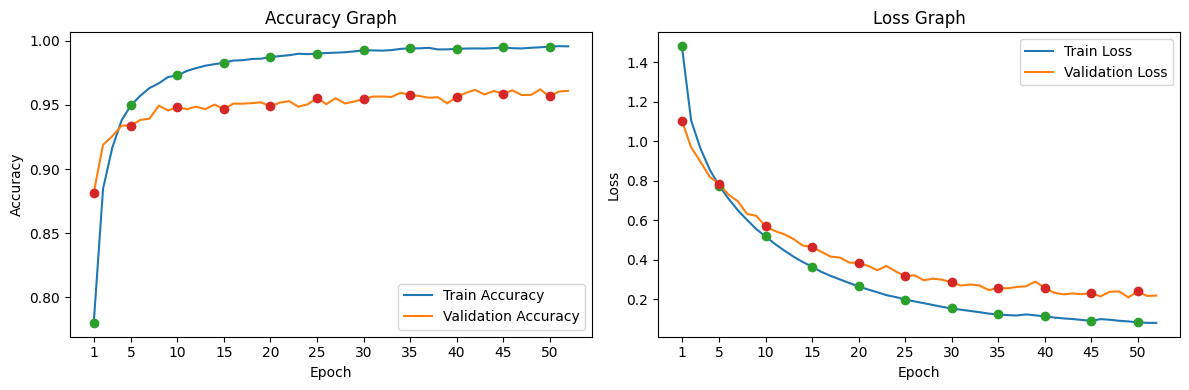

In [ ]:
# 🔹 Epoch sayısı
epochs = range(1, len(old_history2['accuracy']) + 1)

# 🔹 Gösterilecek epochlar
selected_epochs = [1] + list(range(5, len(epochs)+1, 5))

plt.figure(figsize=(12,4))

# ================= ACCURACY =================
plt.subplot(1,2,1)

# Çizgi
plt.plot(epochs, old_history2['accuracy'], label='Train Accuracy')
plt.plot(epochs, old_history2['val_accuracy'], label='Validation Accuracy')

# 🔹 Sadece seçilen epochlarda nokta koy
plt.plot(selected_epochs,
         [old_history2['accuracy'][i-1] for i in selected_epochs],
         'o')

plt.plot(selected_epochs,
         [old_history2['val_accuracy'][i-1] for i in selected_epochs],
         'o')

plt.title('Accuracy Graph')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.xticks(selected_epochs)
plt.legend()

# ================= LOSS =================
plt.subplot(1,2,2)

# Çizgi
plt.plot(epochs, old_history2['loss'], label='Train Loss')
plt.plot(epochs, old_history2['val_loss'], label='Validation Loss')

# 🔹 Sadece seçilen epochlarda nokta koy
plt.plot(selected_epochs,
         [old_history2['loss'][i-1] for i in selected_epochs],
         'o')

plt.plot(selected_epochs,
         [old_history2['val_loss'][i-1] for i in selected_epochs],
         'o')

plt.title('Loss Graph')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.xticks(selected_epochs)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/bestModel_final_v2.keras")

In [ ]:
test_path = "/content/dataset/test"

images = []
labels = []

for file in os.listdir(test_path):
    img_path = os.path.join(test_path, file)

    # resmi oku
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))
    img = img / 255.0

    images.append(img)

    # label çıkar (A_test.jpg → A)
    label = file.split("_")[0]
    labels.append(label)

X_test = np.array(images)

In [ ]:
X_test.shape

(28, 224, 224, 3)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# Prediction
y_pred = model.predict(X_test)
Y_pred_classes = np.argmax(y_pred, axis=1)

# Class mapping
class_indices = train_generator.class_indices
index_to_class = {v: k for k, v in class_indices.items()}

# True label → index'e çevir
Y_true = [class_indices[label] for label in labels]

# Accuracy
accuracy = np.mean(np.array(Y_true) == np.array(Y_pred_classes))
print("\nAccuracy:", accuracy, "\n")

# Classification Report
print("Classification Report:\n")
print(classification_report(Y_true, Y_pred_classes, target_names=list(class_indices.keys())))

1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step

Accuracy: 1.0 

Classification Report:

              precision    recall  f1-score   support

           A       1.00      1.00      1.00         1
           B       1.00      1.00      1.00         1
           C       1.00      1.00      1.00         1
           D       1.00      1.00      1.00         1
           E       1.00      1.00      1.00         1
           F       1.00      1.00      1.00         1
           G       1.00      1.00      1.00         1
           H       1.00      1.00      1.00         1
           I       1.00      1.00      1.00         1
           J       1.00      1.00      1.00         1
           K       1.00      1.00      1.00         1
           L       1.00      1.00      1.00         1
           M       1.00      1.00      1.00         1
           N       1.00      1.00      1.00         1
           O       1.00      1.00      1.00         1
           P       1.00      1.00      1.00         1
  

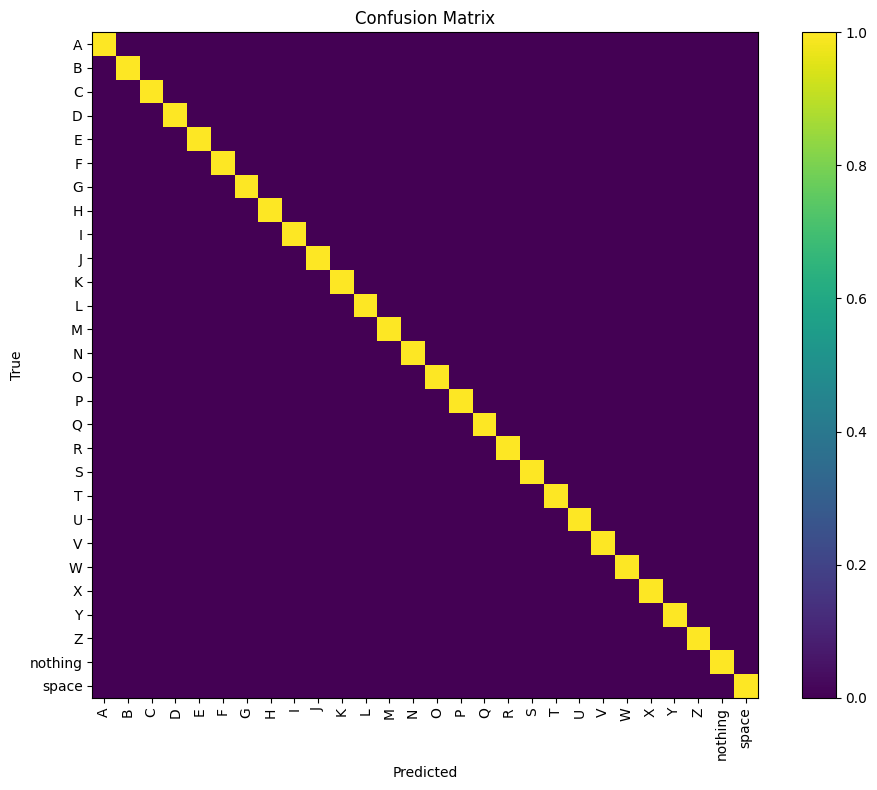

In [ ]:
confusion_mtx = confusion_matrix(Y_true, Y_pred_classes)

plt.figure(figsize=(10, 8))
plt.imshow(confusion_mtx)
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_indices))
plt.xticks(tick_marks, list(class_indices.keys()), rotation=90)
plt.yticks(tick_marks, list(class_indices.keys()))

plt.xlabel("Predicted")
plt.ylabel("True")

plt.tight_layout()
plt.show()

In [ ]:
val_generator.reset()
y_pred = model.predict(val_generator)
Y_pred_classes = np.argmax(y_pred, axis=1)
Y_true = val_generator.classes
Y_pred_classes = Y_pred_classes[:len(Y_true)]

accuracy = np.mean(Y_true == Y_pred_classes)
print("Accuracy:", accuracy)

1050/1050 ━━━━━━━━━━━━━━━━━━━━ 38s 31ms/step
Accuracy: 0.9620833333333333


Classification Report:

              precision    recall  f1-score   support

           A       0.96      1.00      0.98       600
           B       1.00      1.00      1.00       600
           C       1.00      1.00      1.00       600
           D       1.00      0.99      1.00       600
           E       0.91      1.00      0.95       600
           F       0.99      1.00      1.00       600
           G       0.97      0.97      0.97       600
           H       0.92      1.00      0.96       600
           I       1.00      0.83      0.91       600
           J       0.92      0.92      0.92       600
           K       1.00      0.99      0.99       600
           L       1.00      1.00      1.00       600
           M       0.98      0.97      0.98       600
           N       0.90      0.98      0.94       600
           O       0.99      0.96      0.98       600
           P       1.00      0.98      0.99       600
           Q       1.00      1.00      1.00       600
   

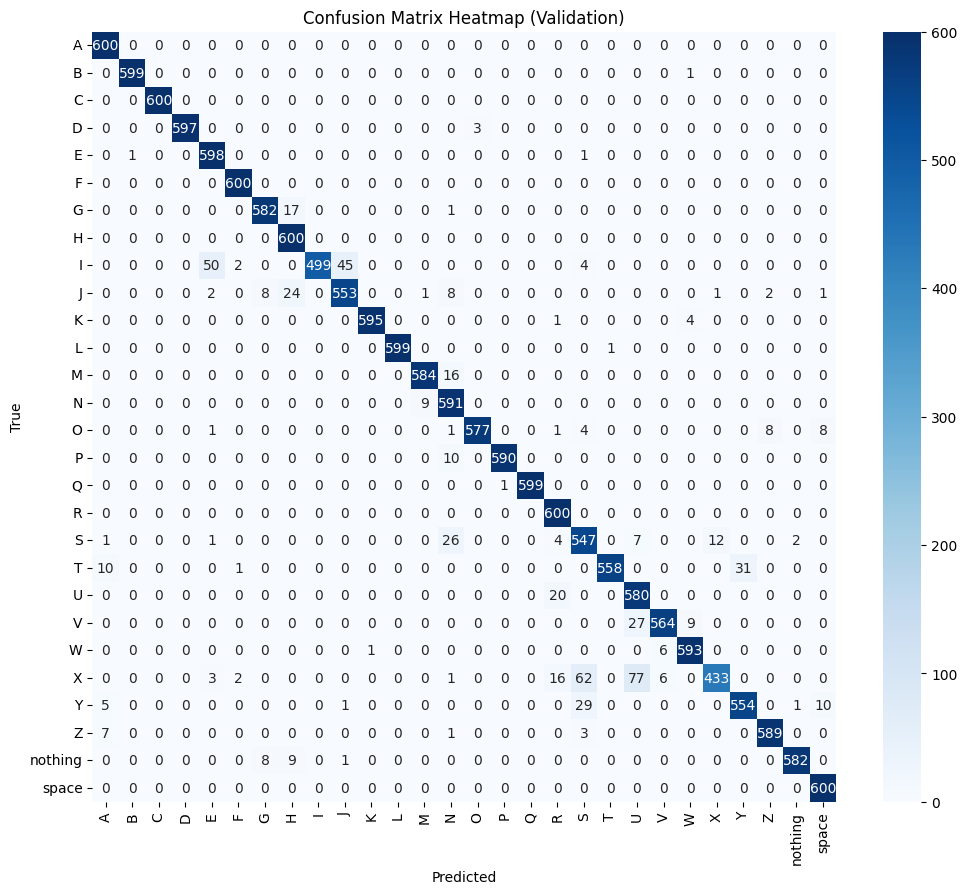

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 🔹 Classification Report
class_labels = list(val_generator.class_indices.keys())
print("Classification Report:\n")
print(classification_report(Y_true, Y_pred_classes, target_names=class_labels))

# 🔹 Confusion Matrix
conf_matrix = confusion_matrix(Y_true, Y_pred_classes)

plt.figure(figsize=(12,10))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix Heatmap (Validation)')
plt.show()

In [ ]:
# Reset the generator to ensure predictions align with the true labels
val_generator.reset()

print("Fetching predictions, this may take a while depending on the dataset size...")
# Get the prediction probabilities from the model
Y_pred_probs = model.predict(val_generator)

# Use Keras's built-in sparse_top_k_categorical_accuracy function
top2_acc = tf.keras.metrics.sparse_top_k_categorical_accuracy(Y_true, Y_pred_probs, k=2)
top3_acc = tf.keras.metrics.sparse_top_k_categorical_accuracy(Y_true, Y_pred_probs, k=3)

# Average the results and convert to numpy format
top2_score = np.mean(top2_acc.numpy())
top3_score = np.mean(top3_acc.numpy())

print("-" * 35)
print(f"Top-1 Accuracy (Standard) : 96.21%") # The baseline value achieved
print(f"Top-2 Accuracy            : {top2_score * 100:.2f}%")
print(f"Top-3 Accuracy            : {top3_score * 100:.2f}%")
print("-" * 35)

Fetching predictions, this may take a while depending on the dataset size...
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 29s 28ms/step
-----------------------------------
Top-1 Accuracy (Standard) : 96.21%
Top-2 Accuracy            : 98.61%
Top-3 Accuracy            : 99.26%
-----------------------------------


In [ ]:
gap_total = sum(t- v for t, v in zip(old_history2['accuracy'], old_history2['val_accuracy']))
print(gap_total/52)

0.02870363799425272
